In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

Loading the datasets

In [2]:
train = pd.read_csv("train.csv")
public_test = pd.read_csv("public_test.csv")
private_test = pd.read_csv("private_test.csv")

In [3]:
print("Train Dataset :", train.shape)
print("Public Test Dataset :", public_test.shape)
print("Private Test Dataset :", private_test.shape)

Train Dataset : (10000, 14)
Public Test Dataset : (3000, 14)
Private Test Dataset : (3000, 13)


In [4]:
train.head()

,User_ID,Age,Income,City_Tier,Device_Type,Traffic_Source,Pages_Viewed,Products_Viewed,Time_On_Site,Previous_Purchases,Discount_Seen,Browser_Version,Campaign_Code,Converted
0,1,58.0,103593.708812,2,Mobile,Organic,5,4,9.61,3,0,11,2418,0
1,2,26.0,36451.716984,2,Mobile,Social Media,11,3,17.63,2,0,14,1213,0
2,3,19.0,30511.228700,3,Mobile,Referral,1,1,13.25,5,0,5,2849,0
3,4,48.0,87789.172342,3,Mobile,Email,14,12,NaN,1,1,19,7610,0
4,5,35.0,105229.249067,2,Mobile,Social Media,14,21,16.92,1,0,5,9261,0


In [5]:
public_test.head()

,User_ID,Age,Income,City_Tier,Device_Type,Traffic_Source,Pages_Viewed,Products_Viewed,Time_On_Site,Previous_Purchases,Discount_Seen,Browser_Version,Campaign_Code,Converted
0,100001,50.0,65922.413596,3,Tablet,Organic,15,16,NaN,2,0,13,5698,1
1,100002,39.0,43205.865640,1,Mobile,Paid Ads,17,16,12.72,2,1,10,7011,0
2,100003,NaN,44333.908253,3,Mobile,Organic,17,15,3.13,5,0,21,8265,1
3,100004,22.0,141906.816221,3,Desktop,Social Media,1,2,25.32,3,0,9,5592,0
4,100005,47.0,39521.673456,1,Mobile,Social Media,2,4,NaN,3,1,9,4128,0


In [6]:
train.columns

Index(['User_ID', 'Age', 'Income', 'City_Tier', 'Device_Type',
       'Traffic_Source', 'Pages_Viewed', 'Products_Viewed', 'Time_On_Site',
       'Previous_Purchases', 'Discount_Seen', 'Browser_Version',
       'Campaign_Code', 'Converted'],
      dtype='object')

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   User_ID             10000 non-null  int64  
 1   Age                 8520 non-null   float64
 2   Income              9016 non-null   float64
 3   City_Tier           10000 non-null  int64  
 4   Device_Type         10000 non-null  object 
 5   Traffic_Source      10000 non-null  object 
 6   Pages_Viewed        10000 non-null  int64  
 7   Products_Viewed     10000 non-null  int64  
 8   Time_On_Site        8152 non-null   float64
 9   Previous_Purchases  10000 non-null  int64  
 10  Discount_Seen       10000 non-null  int64  
 11  Browser_Version     10000 non-null  int64  
 12  Campaign_Code       10000 non-null  int64  
 13  Converted           10000 non-null  int64  
dtypes: float64(3), int64(9), object(2)
memory usage: 1.1+ MB


In [8]:
train.describe()


,User_ID,Age,Income,City_Tier,Pages_Viewed,Products_Viewed,Time_On_Site,Previous_Purchases,Discount_Seen,Browser_Version,Campaign_Code,Converted
count,10000.00000,8520.000000,9016.000000,10000.000000,10000.00000,10000.000000,8152.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,41.457746,69961.772797,1.933400,15.60850,15.219300,13.667241,2.972500,0.540700,12.473900,5511.162200,0.30870
std,2886.89568,13.770164,24790.673822,0.737712,8.62346,8.927563,19.438244,1.738691,0.498366,6.892856,2596.933802,0.46198
min,1.00000,18.000000,12000.000000,1.000000,1.00000,1.000000,0.800000,0.000000,0.000000,1.000000,1000.000000,0.00000
25%,2500.75000,29.000000,52294.644359,1.000000,8.00000,8.000000,7.640000,2.000000,0.000000,7.000000,3251.750000,0.00000
50%,5000.50000,41.000000,70171.613672,2.000000,16.00000,15.000000,11.145000,3.000000,1.000000,12.000000,5515.500000,0.00000
75%,7500.25000,53.000000,86907.747154,2.000000,23.00000,23.000000,15.630000,4.000000,1.000000,18.000000,7759.000000,1.00000
max,10000.00000,65.000000,161687.774167,3.000000,30.00000,37.000000,607.390000,12.000000,1.000000,24.000000,9998.000000,1.00000


In [9]:
train.isnull().sum()

User_ID                  0
Age                   1480
Income                 984
City_Tier                0
Device_Type              0
Traffic_Source           0
Pages_Viewed             0
Products_Viewed          0
Time_On_Site          1848
Previous_Purchases       0
Discount_Seen            0
Browser_Version          0
Campaign_Code            0
Converted                0
dtype: int64

In [10]:
(train.isnull().sum() / len(train)) * 100

User_ID                0.00
Age                   14.80
Income                 9.84
City_Tier              0.00
Device_Type            0.00
Traffic_Source         0.00
Pages_Viewed           0.00
Products_Viewed        0.00
Time_On_Site          18.48
Previous_Purchases     0.00
Discount_Seen          0.00
Browser_Version        0.00
Campaign_Code          0.00
Converted              0.00
dtype: float64

In [11]:
train["Converted"].value_counts()

Converted
0    6913
1    3087
Name: count, dtype: int64

In [12]:
train["Converted"].value_counts(normalize=True) * 100

Converted
0    69.13
1    30.87
Name: proportion, dtype: float64

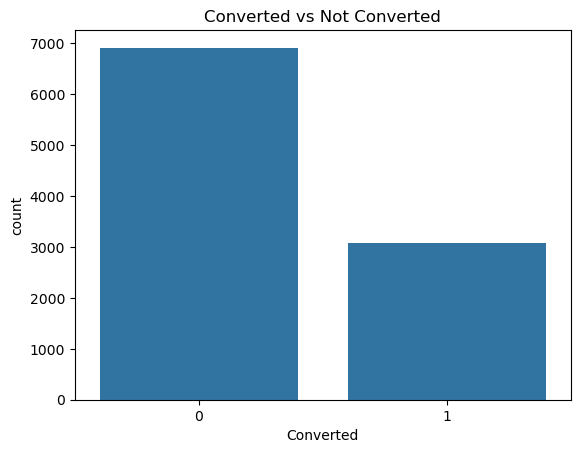

In [13]:
sns.countplot(x="Converted", data=train)
plt.title("Converted vs Not Converted")
plt.show()

In [14]:
num_cols = [
    "Age",
    "Income",
    "Pages_Viewed",
    "Products_Viewed",
    "Time_On_Site",
    "Previous_Purchases"
]
cat_cols = [
    "City_Tier",
    "Device_Type",
    "Traffic_Source",
    "Browser_Version",
    "Campaign_Code"
]

In [15]:
for col in cat_cols:
    print("\nColumn:", col)
    print(train[col].unique())


Column: City_Tier
[2 3 1]

Column: Device_Type
['Mobile' 'Desktop' 'Tablet']

Column: Traffic_Source
['Organic' 'Social Media' 'Referral' 'Email' 'Paid Ads']

Column: Browser_Version
[11 14  5 19 16 23 20  4  7 24 10  2  6 18 22  9 15 21  8 12 17 13  1  3]

Column: Campaign_Code
[2418 1213 2849 ... 8491 9175 7941]


In [16]:
train_data = train.copy()
public_data = public_test.copy()
private_data = private_test.copy()

Observation:
Dataset contains missing values in Age, Income and Time_On_Site.
Target variable is slightly imbalanced.
Both numerical and categorical features are present.
User_ID is only an identifier and may not help in prediction.

Exploratory Data Analysis (EDA)

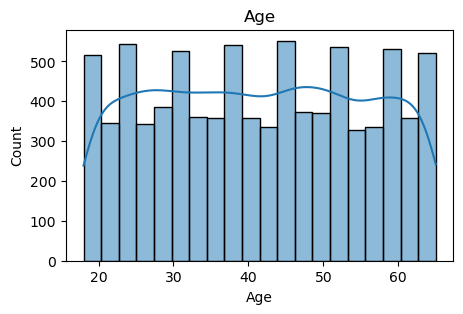

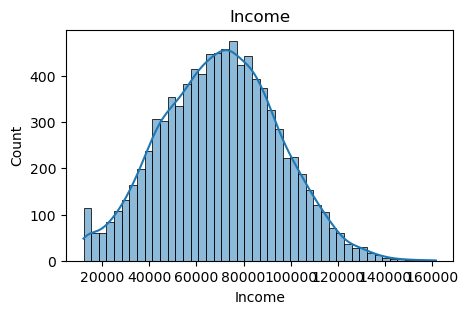

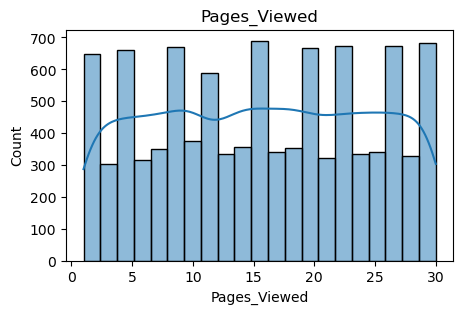

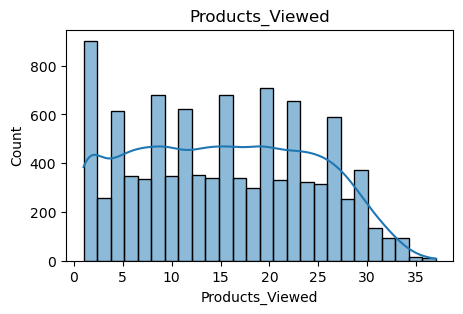

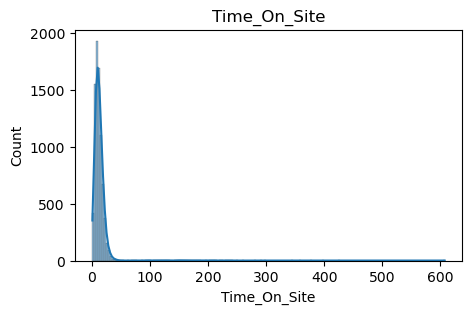

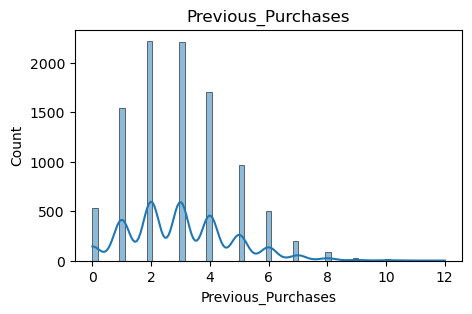

In [17]:
for col in num_cols:    
    plt.figure(figsize=(5,3))
    sns.histplot(train[col], kde=True)
    plt.title(col)
    plt.show()

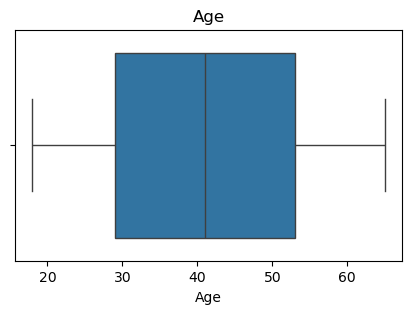

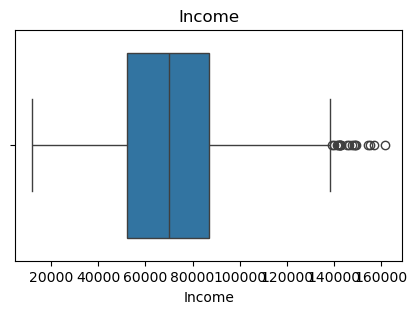

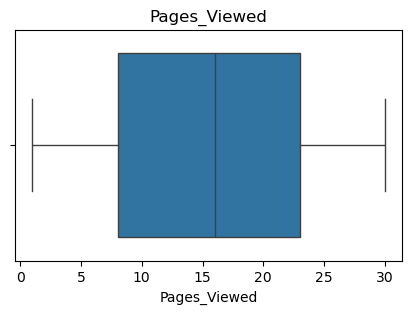

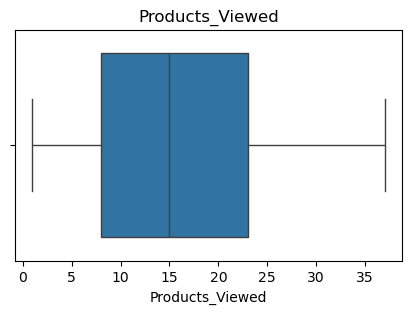

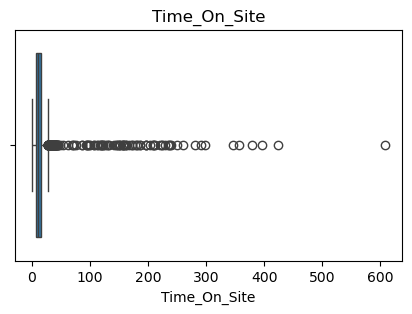

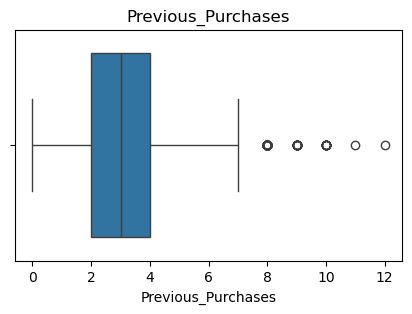

In [18]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=train[col])
    plt.title(col)
    plt.show()

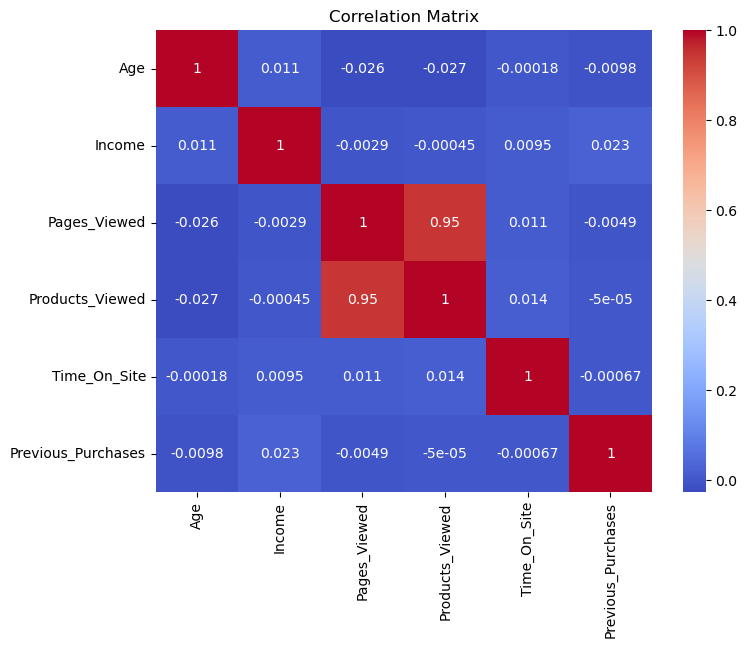

In [19]:
plt.figure(figsize=(8,6))
corr = train[num_cols].corr()
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()

In [20]:
city_conversion = train.groupby(
    "City_Tier"
)["Converted"].mean()
print(city_conversion)

City_Tier
1    0.302991
2    0.320337
3    0.294191
Name: Converted, dtype: float64


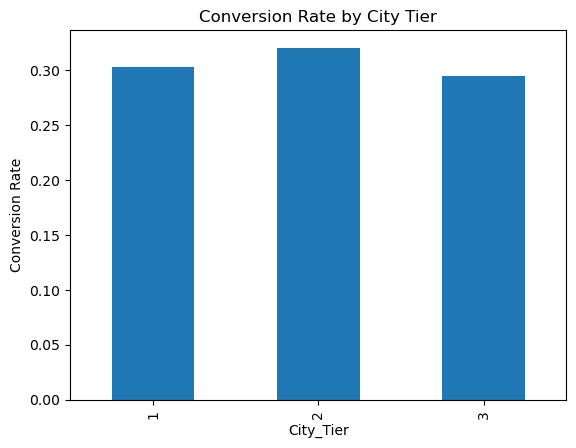

In [21]:
city_conversion.plot(kind="bar")
plt.ylabel("Conversion Rate")
plt.title("Conversion Rate by City Tier")
plt.show()

In [22]:
device_conversion = train.groupby(
    "Device_Type"
)["Converted"].mean()
print(device_conversion)

Device_Type
Desktop    0.330906
Mobile     0.300629
Tablet     0.306468
Name: Converted, dtype: float64


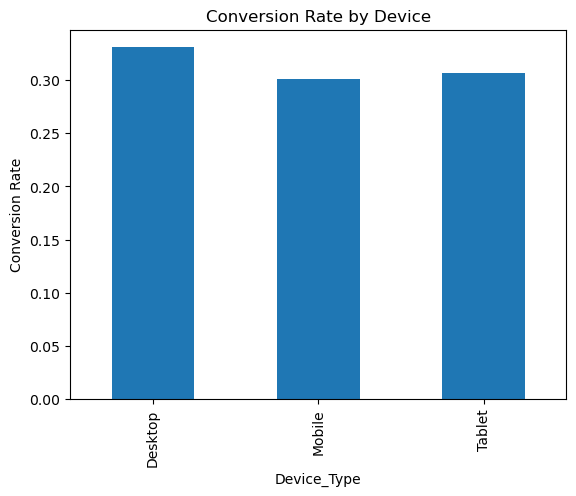

In [23]:
device_conversion.plot(kind="bar")
plt.ylabel("Conversion Rate")
plt.title("Conversion Rate by Device")
plt.show()

In [24]:
traffic_conversion = train.groupby(
    "Traffic_Source"
)["Converted"].mean()
print(traffic_conversion)

Traffic_Source
Email           0.349359
Organic         0.291762
Paid Ads        0.277123
Referral        0.381181
Social Media    0.303061
Name: Converted, dtype: float64


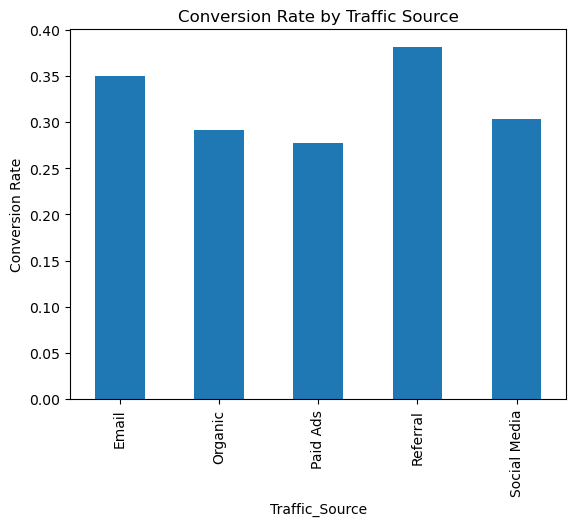

In [25]:
traffic_conversion.plot(kind="bar")
plt.ylabel("Conversion Rate")
plt.title("Conversion Rate by Traffic Source")
plt.show()

In [26]:
discount_conversion = train.groupby(
    "Discount_Seen"
)["Converted"].mean()
print(discount_conversion)

Discount_Seen
0    0.255171
1    0.354171
Name: Converted, dtype: float64


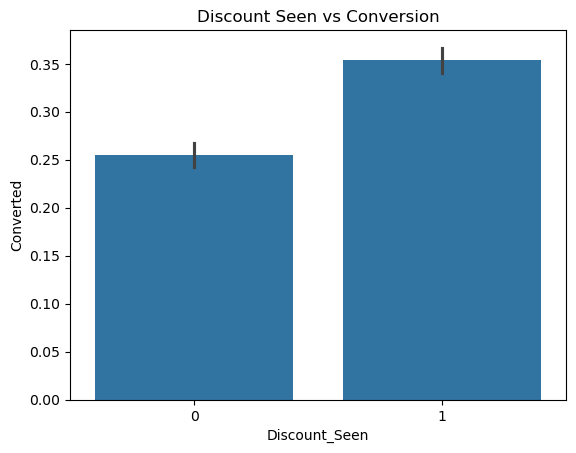

In [27]:
sns.barplot(
    x="Discount_Seen",
    y="Converted",
    data=train
)
plt.title("Discount Seen vs Conversion")
plt.show()

In [28]:
train.groupby(
    "Converted"
)["Income"].mean()

Converted
0    69134.659095
1    71771.595850
Name: Income, dtype: float64

In [29]:
train.groupby(
    "Converted"
)["Time_On_Site"].mean()

Converted
0    12.597556
1    15.925828
Name: Time_On_Site, dtype: float64

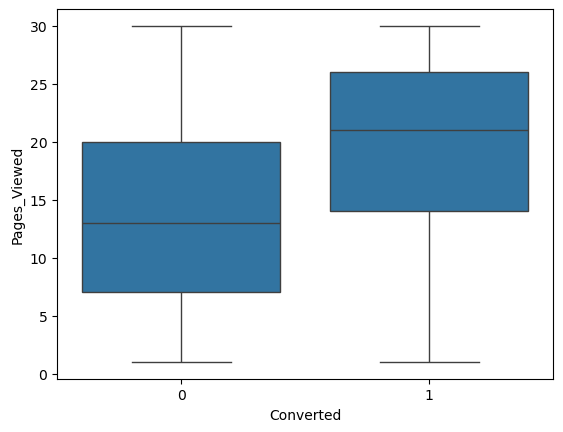

In [30]:
sns.boxplot(
    x="Converted",
    y="Pages_Viewed",
    data=train
)
plt.show()

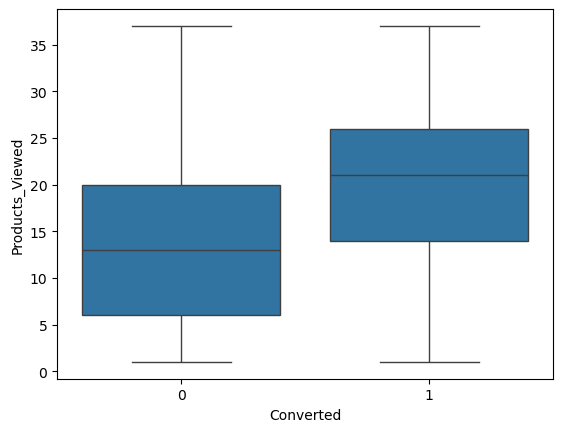

In [31]:
sns.boxplot(
    x="Converted",
    y="Products_Viewed",
    data=train
)
plt.show()

Observations:
1. Dataset contains missing values in Age, Income and Time_On_Site.
2. Converted users generally spend more time on the website.
3. Users who view more products tend to convert more often.
4. Conversion rate differs across traffic sources and device types.
5. Discount visibility appears to have some effect on conversion.
6. No extremely strong correlations were observed among numerical features.

Data Preprocessing

In [32]:
train_data.isnull().sum()

User_ID                  0
Age                   1480
Income                 984
City_Tier                0
Device_Type              0
Traffic_Source           0
Pages_Viewed             0
Products_Viewed          0
Time_On_Site          1848
Previous_Purchases       0
Discount_Seen            0
Browser_Version          0
Campaign_Code            0
Converted                0
dtype: int64

In [33]:
train_data["Age"].fillna(
    train_data["Age"].median(),
    inplace=True
)
train_data["Income"].fillna(
    train_data["Income"].median(),
    inplace=True
)
train_data["Time_On_Site"].fillna(
    train_data["Time_On_Site"].median(),
    inplace=True
)

In [34]:
public_data["Age"].fillna(
    train_data["Age"].median(),
    inplace=True
)
public_data["Income"].fillna(
    train_data["Income"].median(),
    inplace=True
)
public_data["Time_On_Site"].fillna(
    train_data["Time_On_Site"].median(),
    inplace=True
)

In [35]:
private_data["Age"].fillna(
    train_data["Age"].median(),
    inplace=True
)
private_data["Income"].fillna(
    train_data["Income"].median(),
    inplace=True
)
private_data["Time_On_Site"].fillna(
    train_data["Time_On_Site"].median(),
    inplace=True
)

In [36]:
print(train_data.isnull().sum().sum())
print(public_data.isnull().sum().sum())
print(private_data.isnull().sum().sum())

0
0
0


In [37]:
cat_cols = [
    "City_Tier",
    "Device_Type",
    "Traffic_Source",
    "Browser_Version",
    "Campaign_Code"
]

In [38]:
for col in cat_cols:

    le = LabelEncoder()

    combined = pd.concat([
        train_data[col],
        public_data[col],
        private_data[col]
    ])

    le.fit(combined)

    train_data[col] = le.transform(train_data[col])

    public_data[col] = le.transform(public_data[col])

    private_data[col] = le.transform(private_data[col])

In [39]:
X = train_data.drop(
    ["User_ID", "Converted"],
    axis=1
)
y = train_data["Converted"]

In [40]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [41]:
num_cols = [
    "Age",
    "Income",
    "Pages_Viewed",
    "Products_Viewed",
    "Time_On_Site",
    "Previous_Purchases"
]

In [42]:
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(
    X_train[num_cols]
)
X_valid[num_cols] = scaler.transform(
    X_valid[num_cols]
)

In [43]:
X_public = public_data.drop(
    ["User_ID", "Converted"],
    axis=1
)
y_public = public_data["Converted"]

In [44]:
X_public[num_cols] = scaler.transform(
    X_public[num_cols]
)

In [45]:
X_private = private_data.drop(
    ["User_ID"],
    axis=1
)

In [46]:
X_private[num_cols] = scaler.transform(
    X_private[num_cols]
)

In [47]:
print(X_train.shape)
print(X_valid.shape)
print(X_public.shape)
print(X_private.shape)

(8000, 12)
(2000, 12)
(3000, 12)
(3000, 12)


Observations:

1. Missing values were present in Age, Income and Time_On_Site.
2. Median imputation was used to handle missing values.
3. Categorical features were converted into numerical form using Label Encoding.
4. Numerical features were standardized before applying Logistic Regression.
5. User_ID was removed since it does not contribute to prediction.

Logistic Regression Model

In [48]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)
lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [49]:
train_pred = lr_model.predict(X_train)
print(
    "Training Accuracy:",
    accuracy_score(y_train, train_pred)
)

Training Accuracy: 0.709875


In [50]:
valid_pred = lr_model.predict(X_valid)

In [51]:
print(
    "Validation Accuracy:",
    accuracy_score(y_valid, valid_pred)
)

Validation Accuracy: 0.713


In [52]:
f1 = f1_score(
    y_valid,
    valid_pred
)

print("Validation F1 Score:", f1)

Validation F1 Score: 0.3801295896328294


In [53]:
print(
    classification_report(
        y_valid,
        valid_pred
    )
)

              precision    recall  f1-score   support

           0       0.74      0.90      0.81      1383
           1       0.57      0.29      0.38       617

    accuracy                           0.71      2000
   macro avg       0.65      0.59      0.60      2000
weighted avg       0.69      0.71      0.68      2000



In [54]:
cm = confusion_matrix(
    y_valid,
    valid_pred
)
print(cm)

[[1250  133]
 [ 441  176]]


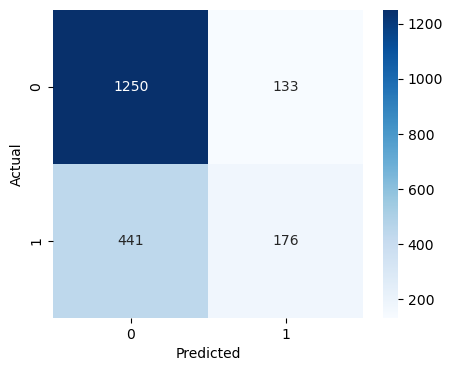

In [55]:
plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [56]:
valid_prob = lr_model.predict_proba(X_valid)[:,1]
auc = roc_auc_score(
    y_valid,
    valid_prob
)
print("ROC AUC Score:", auc)

ROC AUC Score: 0.7259955631651297


In [57]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr_model.coef_[0]
})
feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
9,Discount_Seen,0.592373
5,Pages_Viewed,0.452157
6,Products_Viewed,0.315022
8,Previous_Purchases,0.221731
7,Time_On_Site,0.198182
1,Income,0.088758
4,Traffic_Source,0.017478
11,Campaign_Code,0.000001
10,Browser_Version,-0.000134
0,Age,-0.006077


In [58]:
feature_importance.sort_values(
    by="Coefficient",
    ascending=False
).head(10)

,Feature,Coefficient
9,Discount_Seen,0.592373
5,Pages_Viewed,0.452157
6,Products_Viewed,0.315022
8,Previous_Purchases,0.221731
7,Time_On_Site,0.198182
1,Income,0.088758
4,Traffic_Source,0.017478
11,Campaign_Code,0.000001
10,Browser_Version,-0.000134
0,Age,-0.006077


In [59]:
feature_importance.sort_values(
    by="Coefficient"
).head(10)

,Feature,Coefficient
3,Device_Type,-0.088003
2,City_Tier,-0.041753
0,Age,-0.006077
10,Browser_Version,-0.000134
11,Campaign_Code,0.000001
4,Traffic_Source,0.017478
1,Income,0.088758
7,Time_On_Site,0.198182
8,Previous_Purchases,0.221731
6,Products_Viewed,0.315022


In [60]:
public_pred = lr_model.predict(X_public)

In [61]:
print(
    "Public Test Accuracy:",
    accuracy_score(
        y_public,
        public_pred
    )
)

Public Test Accuracy: 0.7263333333333334


In [62]:
public_f1 = f1_score(
    y_public,
    public_pred
)

print(
    "Public Test F1 Score:",
    public_f1
)

Public Test F1 Score: 0.4072202166064982


In [63]:
print(
    classification_report(
        y_public,
        public_pred
    )
)

              precision    recall  f1-score   support

           0       0.76      0.90      0.82      2114
           1       0.57      0.32      0.41       886

    accuracy                           0.73      3000
   macro avg       0.66      0.61      0.61      3000
weighted avg       0.70      0.73      0.70      3000



In [64]:
train_acc = accuracy_score(
    y_train,
    train_pred
)
valid_acc = accuracy_score(
    y_valid,
    valid_pred
)
print("Train Accuracy :", train_acc)
print("Validation Accuracy :", valid_acc)

Train Accuracy : 0.709875
Validation Accuracy : 0.713


Model Observations:
1. Logistic Regression was used as the baseline classification model.
2. Numerical features were standardized before training.
3. Model performance was evaluated using Accuracy, ROC-AUC and F1 Score.
4. Public test performance was also checked to estimate generalization ability.
5. Logistic Regression provides interpretable coefficients which help understand feature influence.

Prediction and Submission

In [65]:
private_pred = lr_model.predict(X_private)

In [66]:
print(private_pred[:10])

[0 0 0 0 0 0 0 0 0 0]


In [67]:
submission = pd.DataFrame({
    "User_ID": private_data["User_ID"],
    "Converted": private_pred
})

In [68]:
submission.head()

,User_ID,Converted
0,103001,0
1,103002,0
2,103003,0
3,103004,0
4,103005,0


In [69]:
print(submission.shape)

(3000, 2)


In [70]:
submission["Converted"].value_counts()

Converted
0    2523
1     477
Name: count, dtype: int64

In [71]:
submission["Converted"].value_counts(normalize=True) * 100

Converted
0    84.1
1    15.9
Name: proportion, dtype: float64

In [72]:
submission.to_csv(
    "submission.csv",
    index=False
)
print("Submission file created successfully")

Submission file created successfully


In [73]:
saved_file = pd.read_csv("submission.csv")
saved_file.head()

,User_ID,Converted
0,103001,0
1,103002,0
2,103003,0
3,103004,0
4,103005,0


In [74]:
saved_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   User_ID    3000 non-null   int64
 1   Converted  3000 non-null   int64
dtypes: int64(2)
memory usage: 47.0 KB


In [75]:
public_accuracy = accuracy_score(
    y_public,
    public_pred
)
print("Public Test Accuracy:", public_accuracy)

Public Test Accuracy: 0.7263333333333334
